# SBI feature selection — choosing the summary-stat vector

**Goal.** Pick a scalar summary-stat vector for SBI that

1. **tracks the update matrix** — the UM is order-specific and is what currently discriminates BE vs SC, so a scalar that correlates with UM cells carries that discriminative signal in an *order-invariant* form SBI can use; and
2. **recovers the model parameters**,

while dropping redundant stats (keep one of `x` / `x_rate`).

**Substrate.** One cohort of BE and SC simulations (all parameters varied), uniform stimuli, `N_TRIALS` as a single mega-session per simulated animal.

**Workflow.** simulate once (cached) → three diagnostics (UM-tracking · param-recovery · redundancy) → curate a shortlist → validate with `select_stats` → write `SBI_STATS`.

*Note:* the simulate cell is slow (a full `N_SIMS=2000 × N_TRIALS=2000` cohort with the history stats is tens of minutes locally); it caches to a `.pkl`, so everything downstream reloads from disk. This is torch-free.

In [1]:
import sys, time, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# repo root on the path (works wherever the notebook sits)
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'inference').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from validation.feature_diagnostics import (
    simulate_selection_cohort, um_scalar_correlation, stat_correlation,
    stat_individual_power, select_stats)
from inference.constants import SBI_STATS

# ── config ───────────────────────────────────────────────────────────────────
DISTRIBUTION = 'uniform'
N_SIMS   = 2000          # BE and SC each — rows for the correlations / recovery
N_TRIALS = 2000          # one mega-session per simulated animal
SCORER   = 'gbm'         # 'gbm' (default) | 'rf' | 'ridge' (fast iteration)
SEED     = 0
POOL = [
    'accuracy', 'psychometric', 'stimulus_sensitivity', 'hard_accuracy',
    'easy_accuracy', 'side_bias', 'choice_entropy', 'pse',
    'recency', 'stimulus_recency', 'recency_divergence',
    'win_stay', 'win_stay_rate', 'lose_shift', 'perseveration',
    'choice_autocorr', 'logistic_history',
]
CACHE = ROOT / 'notebooks' / f'_cohort_{DISTRIBUTION}_{N_SIMS}x{N_TRIALS}.pkl'
print(f"current SBI_STATS ({len(SBI_STATS)}): {SBI_STATS}")
print(f"candidate pool  ({len(POOL)}): {POOL}")

current SBI_STATS (10): ['accuracy', 'psychometric', 'recency', 'stimulus_recency', 'win_stay', 'lose_shift', 'side_bias', 'stimulus_sensitivity', 'choice_entropy', 'perseveration']
candidate pool  (17): ['accuracy', 'psychometric', 'stimulus_sensitivity', 'hard_accuracy', 'easy_accuracy', 'side_bias', 'choice_entropy', 'pse', 'recency', 'stimulus_recency', 'recency_divergence', 'win_stay', 'win_stay_rate', 'lose_shift', 'perseveration', 'choice_autocorr', 'logistic_history']


## 0 · Simulate the cohort (slow — cached)

Runs the BE/SC simulator once and caches to disk. **Delete the `.pkl` to force a re-run** (e.g. after changing `POOL`, `N_SIMS` or `N_TRIALS`).

In [2]:
if CACHE.exists():
    cohort = pickle.loads(CACHE.read_bytes())
    print(f"loaded cached cohort: {CACHE.name}")
else:
    t = time.time()
    cohort = simulate_selection_cohort(distribution=DISTRIBUTION, n_sims=N_SIMS,
                                       n_trials=N_TRIALS, stat_pool=POOL, seed=SEED)
    CACHE.write_bytes(pickle.dumps(cohort))
    print(f"simulated + cached in {time.time()-t:.0f}s -> {CACHE.name}")
print(f"n_valid = {cohort.n_valid}")
print(f"params  BE = {cohort.param_names['be']}")
print(f"params  SC = {cohort.param_names['sc']}")
print(f"UM cells = {len(cohort.um_cols)} | predictor stats = {len(cohort.pred_cols())}")

simulated + cached in 576s -> _cohort_uniform_2000x2000.pkl
n_valid = {'be': 2000, 'sc': 2000}
params  BE = ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']
params  SC = ['sigma_percep', 'A_repulsion', 'gamma', 'sigma_update']
UM cells = 64 | predictor stats = 27


## 1 · UM tracking — do scalars carry the UM's discriminative content?

For each UM cell, the **max |r| over scalars** says whether *any* scalar tracks it. A UM cell where every |r| is low is discriminative structure the scalar vector cannot see (e.g. the SC stripe) — a warning that identity will suffer no matter which scalars we pick.

In [3]:
DARK = 0.3   # a UM cell whose best scalar |r| < DARK is poorly tracked

um = {m: um_scalar_correlation(cohort, m)['corr'] for m in ('be', 'sc')}
for m in ('be', 'sc'):
    C = um[m]
    best = pd.DataFrame({'max_|r|': C.max(1), 'best_stat': C.idxmax(1)})
    n_dark = int((C.max(1) < DARK).sum())
    print(f"[{m.upper()}] {C.shape[0]} UM cells, {n_dark} poorly tracked (best |r| < {DARK})")
    display(best.sort_values('max_|r|').head(12).style.background_gradient(
        subset=['max_|r|'], cmap='RdYlGn', vmin=0, vmax=1).set_caption(
        f'{m.upper()}: worst-tracked UM cells'))

# strongest UM-tracking scalars overall (max |r| over UM cells)
tracker = pd.DataFrame({'BE': um['be'].max(0), 'SC': um['sc'].max(0)}).sort_values('SC', ascending=False)
display(tracker.style.background_gradient(cmap='Greens', vmin=0, vmax=1).set_caption(
    'strongest UM-tracking scalar (max |r| over UM cells)'))

[BE] 64 UM cells, 12 poorly tracked (best |r| < 0.3)


,max_|r|,best_stat
um_7_4,0.181251,recency
um_7_0,0.214921,win_stay_rate
um_7_5,0.234537,recency
um_0_3,0.236843,win_stay_rate
um_0_7,0.244394,win_stay_rate
um_0_2,0.256870,win_stay_rate
um_0_6,0.262309,win_stay_rate
um_7_3,0.290121,recency
um_0_4,0.290217,win_stay_rate
um_0_1,0.295666,w_prev_choice_1


[SC] 64 UM cells, 35 poorly tracked (best |r| < 0.3)


,max_|r|,best_stat
um_7_4,0.073366,w_stimulus
um_0_3,0.092922,win_stay_rate
um_0_2,0.096955,win_stay_rate
um_0_7,0.111668,recency
um_6_4,0.116043,win_stay_rate
um_0_6,0.119008,win_stay_rate
um_0_4,0.130907,win_stay_rate
um_7_0,0.131396,win_stay_rate
um_7_5,0.137304,accuracy
um_0_5,0.138157,recency


,BE,SC
w_prev_choice_1,0.603809,0.607925
perseveration,0.576519,0.550886
recency,0.591676,0.550081
stimulus_recency,0.591676,0.550081
win_stay_rate,0.604351,0.545318
choice_autocorr,0.566411,0.518317
win_stay,0.509259,0.394739
history_decay,0.054749,0.343637
sigma,0.308996,0.335375
hard_accuracy,0.211878,0.328915


## 2 · Parameter recovery + BE/SC identity

`stat_individual_power` scores each stat on its own: a direct BE-vs-SC identity AUC, and per-parameter recovery R² (per model). A stat can be individually strong yet jointly redundant — that's what §3 and §4 are for.

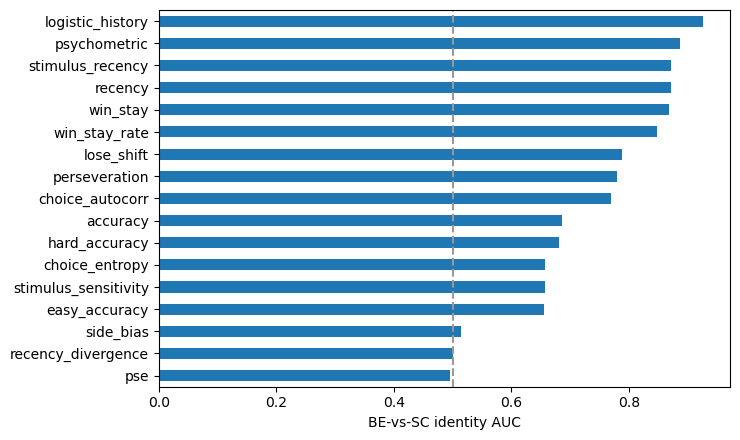

,sigma_percep,A_repulsion,eta_learning,eta_relax,gamma,sigma_update
accuracy,0.66,0.01,-0.02,0.03,0.03,0.32
psychometric,0.77,0.02,-0.02,0.06,0.23,0.53
stimulus_sensitivity,0.73,0.02,-0.02,0.03,0.06,0.28
hard_accuracy,0.23,-0.02,-0.03,-0.00,-0.02,0.21
easy_accuracy,0.70,-0.00,-0.04,0.04,0.06,0.27
side_bias,-0.03,-0.02,-0.02,-0.04,-0.03,-0.04
choice_entropy,0.75,0.01,-0.02,0.04,0.05,0.28
pse,0.02,-0.05,-0.05,-0.06,-0.03,-0.03
recency,-0.03,0.52,0.36,-0.04,-0.06,0.00
stimulus_recency,-0.03,0.52,0.36,-0.04,-0.06,0.00


,best_stat,R2
sigma_percep,logistic_history,0.772119
A_repulsion,logistic_history,0.615198
eta_learning,win_stay,0.451865
eta_relax,psychometric,0.056816
gamma,psychometric,0.226316
sigma_update,psychometric,0.532806


In [4]:
ip = stat_individual_power(cohort, scorer=SCORER, seed=SEED)

auc = ip['identity'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
auc.plot.barh(ax=ax); ax.axvline(0.5, color='0.6', ls='--')
ax.set_xlabel('BE-vs-SC identity AUC'); ax.invert_yaxis(); plt.tight_layout(); plt.show()

# per-param recovery R² (max over the two models: a param is recovered if EITHER model's fit recovers it)
rec = pd.concat({m: ip['recovery'][m] for m in ('be', 'sc')}).groupby(level=1).max().reindex(POOL)
display(rec.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=0.8, axis=None).format('{:.2f}').set_caption(
    'recovery R² (max over models): stats (rows) x parameters (cols)'))

best_rec = pd.DataFrame({'best_stat': rec.idxmax(0), 'R2': rec.max(0)})
display(best_rec.style.background_gradient(subset=['R2'], cmap='RdYlGn', vmin=0, vmax=0.8).set_caption(
    'best single-stat recoverer per parameter'))

## 3 · Redundancy — drop near-duplicate stats

Pairs with |r| near 1 are interchangeable; keep the stronger recoverer / UM-tracker of each pair.

In [5]:
REDUN = 0.9
Cred = stat_correlation(cohort, 'sc')['corr']      # stat x stat (SC; BE is similar)
display(Cred.style.background_gradient(cmap='Reds', vmin=0, vmax=1, axis=None).format('{:.2f}').set_caption(
    'stat-stat |r| (SC) — look for blocks near 1'))

pairs = [(a, b, float(Cred.loc[a, b])) for i, a in enumerate(Cred.index) for b in Cred.index[i+1:]
         if Cred.loc[a, b] > REDUN]
print(f"redundant pairs (|r| > {REDUN}) — keep one of each:")
for a, b, r in sorted(pairs, key=lambda t: -t[2]):
    print(f"  {a:24} ~ {b:24} |r| = {r:.2f}")

,accuracy,mu,sigma,lapse_low,lapse_high,stimulus_sensitivity,hard_accuracy,easy_accuracy,side_bias,choice_entropy,pse,recency,stimulus_recency,recency_divergence,win_stay,win_stay_rate,lose_shift,perseveration,choice_autocorr,w_stimulus,w_prev_choice_1,w_prev_outcome_1,w_prev_choice_2,w_prev_outcome_2,w_prev_choice_3,w_prev_outcome_3,history_decay
accuracy,1.00,0.04,0.80,0.40,0.39,0.98,0.86,0.98,0.02,0.98,0.03,0.16,0.16,nan,0.03,0.15,0.07,0.28,0.27,0.95,0.47,0.07,0.05,0.01,0.02,0.03,0.18
mu,0.04,1.00,0.04,0.27,0.23,0.04,0.02,0.04,0.33,0.03,0.80,0.01,0.01,nan,0.03,0.02,0.05,0.05,0.05,0.02,0.02,0.02,0.02,0.00,0.01,0.02,0.02
sigma,0.80,0.04,1.00,0.15,0.16,0.72,0.80,0.75,0.01,0.76,0.03,0.18,0.18,nan,0.14,0.12,0.09,0.16,0.15,0.72,0.33,0.06,0.09,0.02,0.05,0.01,0.11
lapse_low,0.40,0.27,0.15,1.00,0.82,0.53,0.08,0.48,0.00,0.42,0.15,0.06,0.06,nan,0.21,0.05,0.30,0.22,0.21,0.39,0.24,0.03,0.07,0.01,0.05,0.02,0.12
lapse_high,0.39,0.23,0.16,0.82,1.00,0.52,0.07,0.48,0.04,0.41,0.11,0.05,0.05,nan,0.20,0.05,0.28,0.20,0.20,0.39,0.24,0.01,0.06,0.00,0.06,0.02,0.12
stimulus_sensitivity,0.98,0.04,0.72,0.53,0.52,1.00,0.74,1.00,0.03,0.97,0.04,0.13,0.13,nan,0.02,0.15,0.13,0.30,0.29,0.93,0.47,0.06,0.03,0.01,0.00,0.02,0.19
hard_accuracy,0.86,0.02,0.80,0.08,0.07,0.74,1.00,0.75,0.01,0.82,0.01,0.18,0.18,nan,0.12,0.12,0.07,0.18,0.17,0.81,0.37,0.06,0.09,0.01,0.04,0.04,0.14
easy_accuracy,0.98,0.04,0.75,0.48,0.48,1.00,0.75,1.00,0.03,0.98,0.04,0.14,0.14,nan,0.01,0.15,0.12,0.29,0.28,0.94,0.47,0.07,0.04,0.02,0.01,0.02,0.19
side_bias,0.02,0.33,0.01,0.00,0.04,0.03,0.01,0.03,1.00,0.03,0.65,0.01,0.01,nan,0.00,0.01,0.01,0.02,0.02,0.03,0.02,0.01,0.02,0.02,0.02,0.04,0.04
choice_entropy,0.98,0.03,0.76,0.42,0.41,0.97,0.82,0.98,0.03,1.00,0.03,0.16,0.16,nan,0.02,0.15,0.08,0.28,0.27,0.98,0.49,0.08,0.05,0.01,0.01,0.03,0.18


redundant pairs (|r| > 0.9) — keep one of each:
  recency                  ~ stimulus_recency         |r| = 1.00
  stimulus_sensitivity     ~ easy_accuracy            |r| = 1.00
  accuracy                 ~ easy_accuracy            |r| = 0.98
  choice_entropy           ~ w_stimulus               |r| = 0.98
  accuracy                 ~ choice_entropy           |r| = 0.98
  accuracy                 ~ stimulus_sensitivity     |r| = 0.98
  easy_accuracy            ~ choice_entropy           |r| = 0.98
  stimulus_sensitivity     ~ choice_entropy           |r| = 0.97
  perseveration            ~ choice_autocorr          |r| = 0.96
  accuracy                 ~ w_stimulus               |r| = 0.95
  recency                  ~ win_stay_rate            |r| = 0.94
  stimulus_recency         ~ win_stay_rate            |r| = 0.94
  easy_accuracy            ~ w_stimulus               |r| = 0.94
  stimulus_sensitivity     ~ w_stimulus               |r| = 0.93
  win_stay_rate            ~ choice_autoco

## 4 · Curate the shortlist

Start from the auto-suggestion — each parameter's best recoverer ∪ the strongest UM-trackers, minus redundant duplicates — then **edit `SHORTLIST` by hand** using the tables above. Keep it to ~10-12 stats so `select_stats` can run exhaustively.

In [6]:
K_UM = 6
auto = set(best_rec['best_stat']) | set(tracker.head(K_UM).index)
for a, b, r in pairs:                               # drop the weaker of each redundant pair
    if a in auto and b in auto:
        drop = a if rec.max(1).get(a, 0) < rec.max(1).get(b, 0) else b
        auto.discard(drop)
auto = [s for s in POOL if s in auto]
print("auto-suggested shortlist:", auto)

# --- EDIT BY HAND ---
SHORTLIST = list(auto)
print("SHORTLIST:", SHORTLIST)

auto-suggested shortlist: ['psychometric', 'win_stay', 'win_stay_rate', 'perseveration', 'logistic_history']
SHORTLIST: ['psychometric', 'win_stay', 'win_stay_rate', 'perseveration', 'logistic_history']


## 5 · Validate the shortlist

`select_stats` searches subsets of the shortlist for joint identity AUC + parameter recovery. Its headline `r2_min` is the **min over *all* parameters**, so it looks bad whenever a parameter is inherently unrecoverable from scalars — read the identity AUC and the *per-parameter* recovery of the selected subset (last table) separately, rather than trusting the single number.

In [7]:
from validation.feature_diagnostics import _cv_r2

sel = select_stats(cohort, shortlist=SHORTLIST, scorer=SCORER,
                   method='auto', identity_floor=0.9, seed=SEED)
print(f"search method: {sel['method']}")
display(sel['best_by_k'][['k', 'identity_auc', 'r2_min']].round(3))
print("SELECTED subset:", sorted(sel['selected']))
print(f"  identity AUC = {sel['selected_identity_auc']:.3f}   min param R² = {sel['selected_r2_min']:.3f}")

# per-parameter recovery of the SELECTED subset (not just the min)
cols = sorted({c for g in sel['selected'] for c in cohort.pred_groups[g]})
rows = {m: {p: _cv_r2(SCORER, cohort.X[m][:, cols], cohort.theta[m][:, j], 5, SEED)
            for j, p in enumerate(cohort.param_names[m])} for m in ('be', 'sc')}
display(pd.DataFrame(rows).style.background_gradient(cmap='RdYlGn', vmin=0, vmax=0.8, axis=None).format('{:.2f}').set_caption(
    'selected subset — per-parameter recovery R² (per model)'))

search method: exhaustive


,k,identity_auc,r2_min
0,1,0.926,0.047
1,2,0.952,0.079
2,3,0.972,0.086
3,4,0.972,0.091
4,5,0.973,0.086


SELECTED subset: ['logistic_history', 'psychometric', 'win_stay']
  identity AUC = 0.972   min param R² = 0.086


,be,sc
sigma_percep,0.79,0.41
A_repulsion,0.58,0.67
eta_learning,0.50,nan
eta_relax,0.09,nan
gamma,nan,0.22
sigma_update,nan,0.57


## 6 · Chosen vector

In [8]:
SBI_STATS_NEW = sorted(sel['selected'])
print("Chosen SBI_STATS:")
print(SBI_STATS_NEW)
print(f"\n({len(SBI_STATS_NEW)} stats) — paste into inference/constants.py as SBI_STATS, or keep iterating SHORTLIST above.")

Chosen SBI_STATS:
['logistic_history', 'psychometric', 'win_stay']

(3 stats) — paste into inference/constants.py as SBI_STATS, or keep iterating SHORTLIST above.
